# 07 - Análise Descritiva e Usabilidade de Features para Identificação
Este notebook atende ao passo 4: "Conduct a descriptive analysis of the features and its usability for identification".
Aqui analisamos as features extraídas pelo modelo de *Pose Estimation* (distâncias biométricas e texturas de pelagem) e avaliamos o poder de separabilidade matemática de cada vaca, rumo ao objetivo de identificação individual.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Configurações de plotagem
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="muted")

## 1. Carregamento dos Dados
Vamos carregar o CSV de features extraído no passo `06_feature_extraction.py`.
Certifique-se de que a etapa de extração já foi executada para gerar o arquivo `.csv`.

In [14]:
DATA_DIR = Path('g:/PYTHON/cow/data/processed')
csv_path = DATA_DIR / 'cow_features_geo.csv' # Ou cow_features_geo.csv dependendo do modo rodado

if not csv_path.exists():
    print(f"ERRO: Arquivo não encontrado: {csv_path}.")
    print("Por favor, execute o script '06_feature_extraction.py' primeiro para gerar os dados.")
else:
    df = pd.read_csv(csv_path)
    print(f"Dataset carregado com {df.shape[0]} amostras e {df.shape[1]} colunas.")
    display(df.head())

Dataset carregado com 1280 amostras e 31 colunas.


,filename,cow_id,S1_F1,S1_F2,S1_F3,S1_F4,S1_F5,S1_F6,S1_F7,S1_F8,...,S2_F7,S2_F8,S2_F9,S2_F10,S2_F11,S2_F12,S2_F13,S2_F14,S2_F15,S2_F16
0,20260101_064610_baia19_IPC2.jpg,1106,0.075913,0.042309,0.122230,0.067883,0.069807,0.140855,0.139030,0.024279,...,0.105017,0.018339,0.022134,0.063217,0.059141,0.045259,0.050221,0.042737,0.102986,0.098921
1,20260101_064711_baia19_IPC2.jpg,1106,0.068655,0.038421,0.123963,0.072242,0.072588,0.144059,0.142710,0.023729,...,0.108011,0.017959,0.022535,0.061337,0.058441,0.045487,0.049577,0.042816,0.102337,0.097985
2,20260101_064910_baia19_IPC2.jpg,1106,0.068301,0.038721,0.124121,0.071351,0.072154,0.144633,0.142860,0.024079,...,0.107699,0.018153,0.022584,0.062263,0.058241,0.044534,0.048929,0.043517,0.103870,0.098737
3,20260101_065012_baia19_IPC2.jpg,1106,0.070858,0.039462,0.123815,0.070633,0.071822,0.142966,0.141843,0.023886,...,0.106774,0.017980,0.021747,0.061711,0.058508,0.045581,0.049357,0.044126,0.103537,0.099577
4,20260101_065312_baia19_IPC2.jpg,1106,0.069348,0.039729,0.123813,0.069529,0.073668,0.143326,0.142616,0.023533,...,0.108200,0.017854,0.023059,0.063359,0.057261,0.044609,0.050269,0.041905,0.103375,0.096041


## 2. Verificação de Integridade e Classes
Analisando o balanceamento de imagens disponíveis por ID de vaca.

C:\Users\rpa1t\AppData\Local\Temp\ipykernel_18456\901008186.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


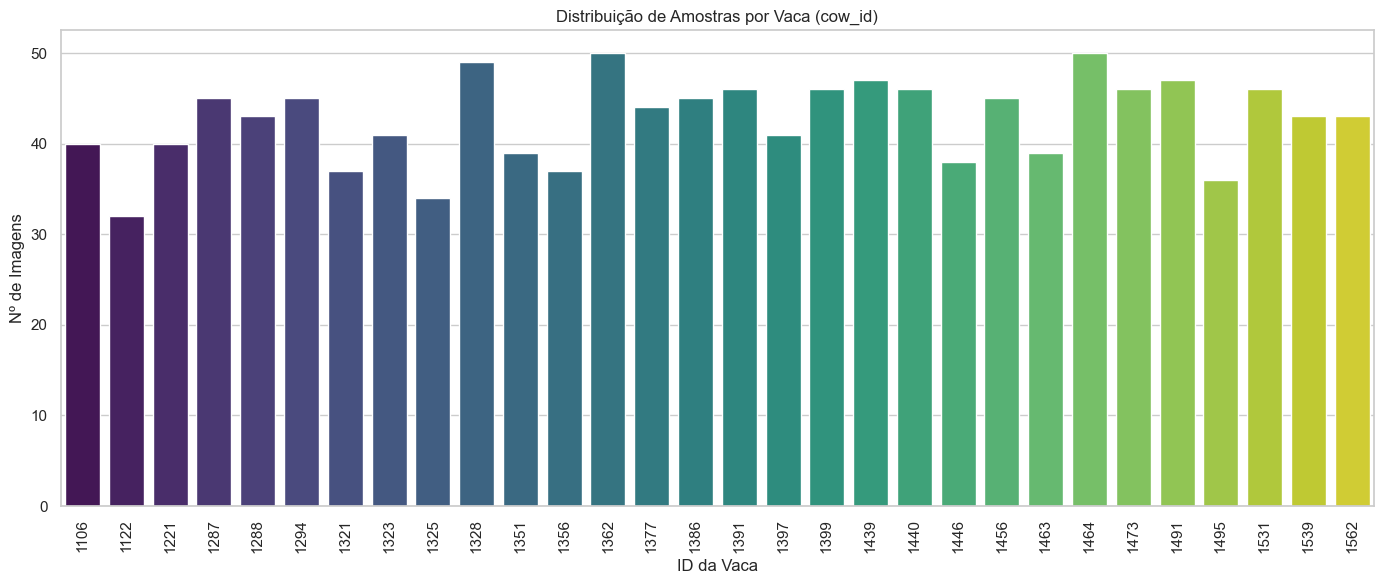

In [15]:
if 'df' in locals():
    plt.figure(figsize=(14, 6))
    class_counts = df['cow_id'].value_counts()
    sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
    plt.title("Distribuição de Amostras por Vaca (cow_id)")
    plt.xticks(rotation=90)
    plt.ylabel("Nº de Imagens")
    plt.xlabel("ID da Vaca")
    plt.tight_layout()
    plt.show()

## 3. Análise de Correlação Colinear
Quais features biométricas ou de pelagem andam juntas? Redundância pode ajudar no PCA e na escolha de algoritmos.

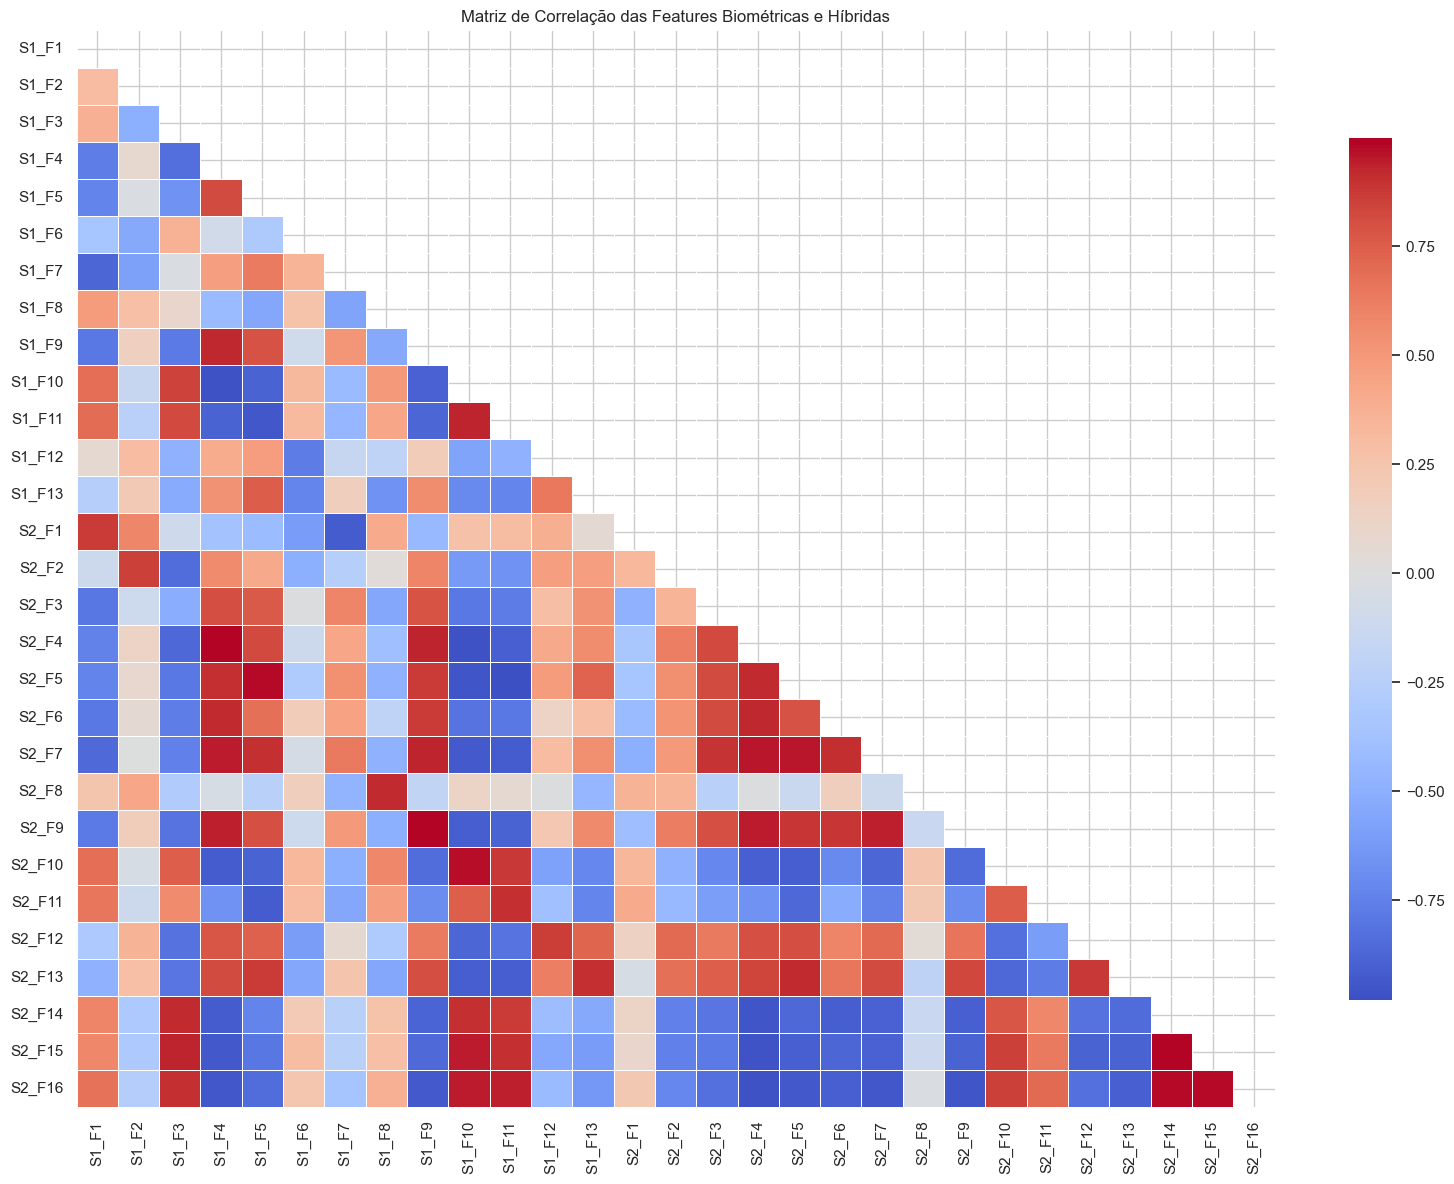

In [16]:
if 'df' in locals():
    features_cols = [c for c in df.columns if c not in ['filename', 'cow_id']]
    df_features = df[features_cols]

    plt.figure(figsize=(16, 12))
    corr = df_features.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=False, fmt=".2f",
                linewidths=.5, cbar_kws={"shrink": .8})
    plt.title("Matriz de Correlação das Features Biométricas e Híbridas")
    plt.tight_layout()
    plt.show()

## 4. Separabilidade Univariada (Boxplots)
Os boxplots confirmam se uma característica visual ou geométrica é estatisticamente diferente para vacas diferentes.

C:\Users\rpa1t\AppData\Local\Temp\ipykernel_18456\1356490068.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cow_id', y=feat, ax=ax, palette="Set3")
C:\Users\rpa1t\AppData\Local\Temp\ipykernel_18456\1356490068.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cow_id', y=feat, ax=ax, palette="Set3")


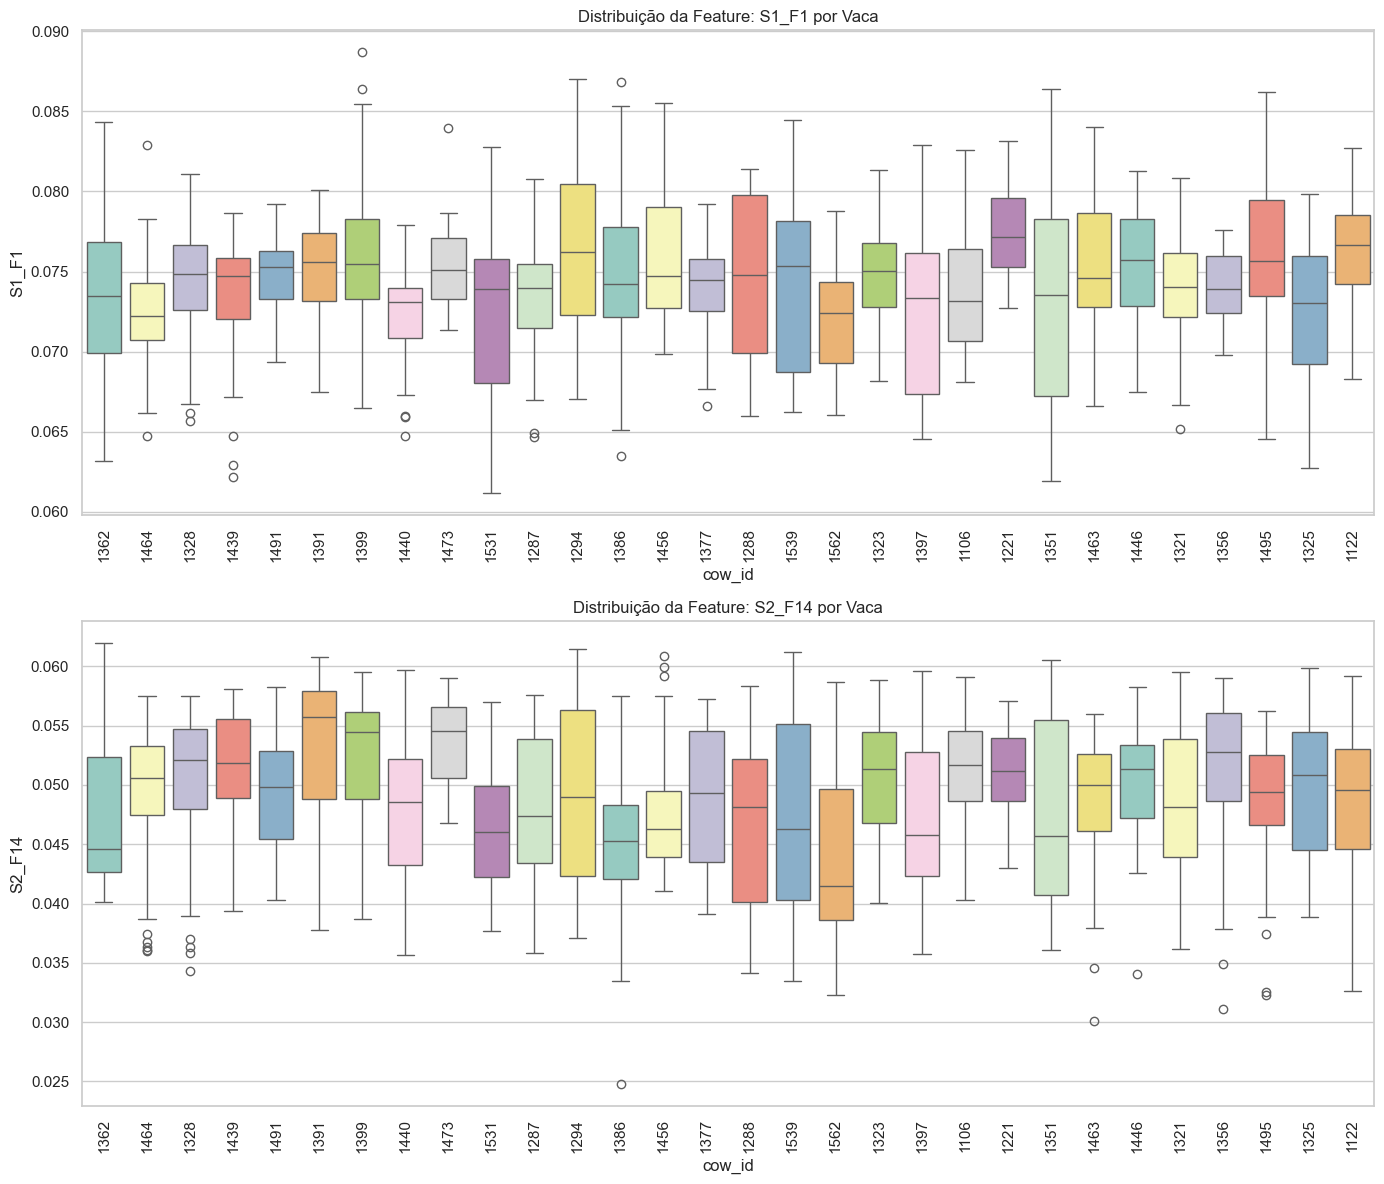

In [17]:
if 'df' in locals():
    # Selecionando algumas features representativas baseadas no estudo e extração
    exemplos = ['S1_F1', 'S2_F14', 'ratio_white_fur', 'texture_contrast']
    exemplos = [e for e in exemplos if e in df.columns]

    if len(exemplos) > 0:
        fig, axes = plt.subplots(len(exemplos), 1, figsize=(14, 6*len(exemplos)))
        if len(exemplos) == 1: axes = [axes]
        
        for ax, feat in zip(axes, exemplos):
            sns.boxplot(data=df, x='cow_id', y=feat, ax=ax, palette="Set3")
            ax.set_title(f"Distribuição da Feature: {feat} por Vaca")
            ax.set_xticks(range(len(class_counts)))
            ax.set_xticklabels(class_counts.index, rotation=90)
        plt.tight_layout()
        plt.show()

## 5. Redução de Dimensionalidade (PCA e t-SNE)
Pode a matemática separar as instâncias no espaço latente? Gráficos de clusterização.

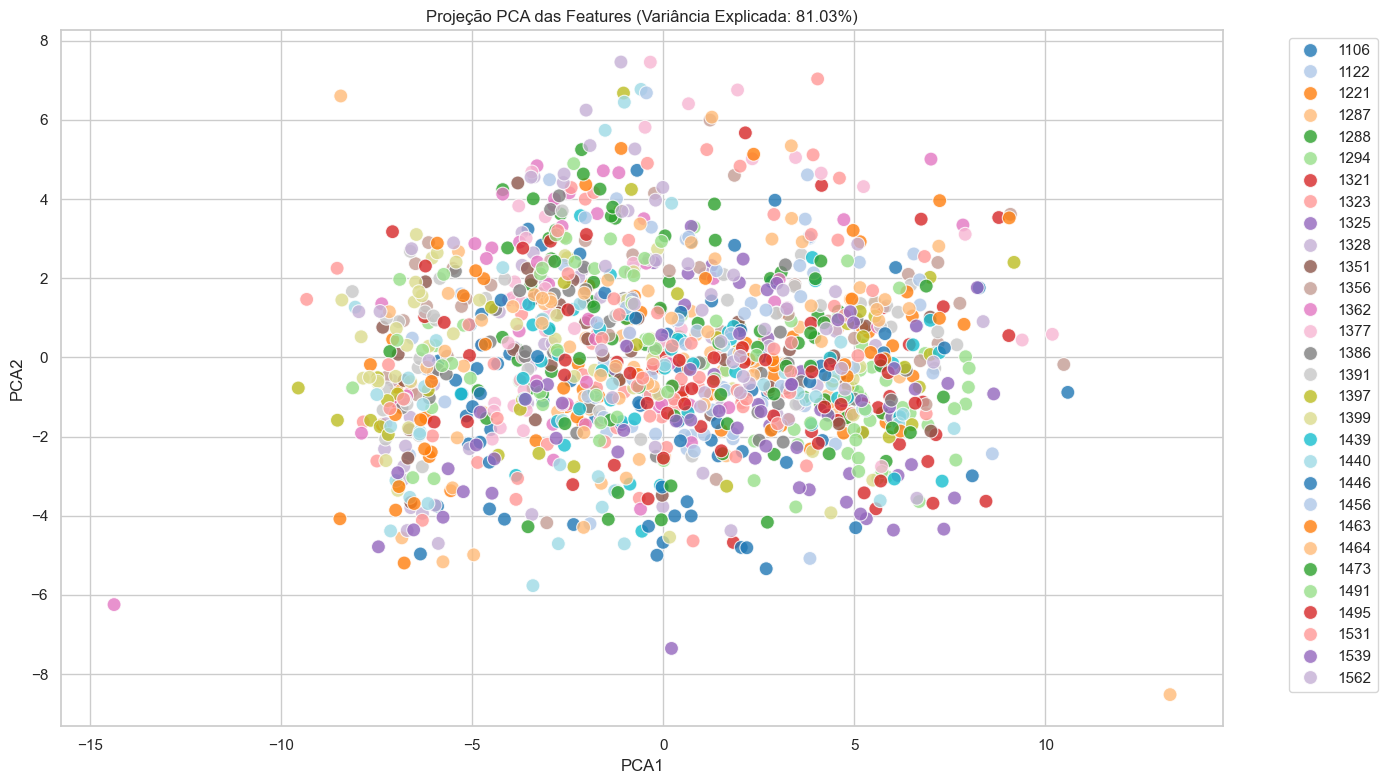

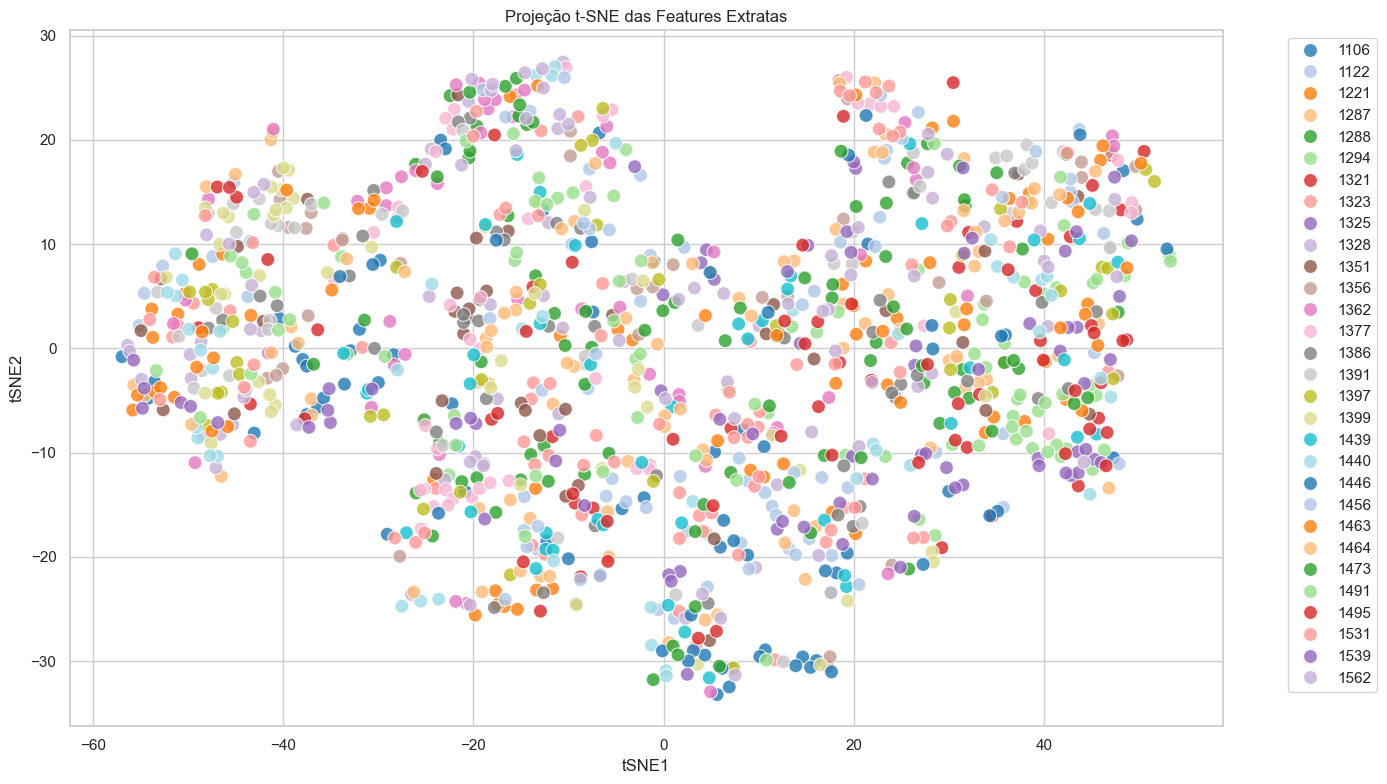

In [18]:
if 'df' in locals():
    # Normalizando os dados antes de projetar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features)
    y = df['cow_id']

    # PCA (Projeção Linear)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df_pca = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'Cow_ID': y})

    plt.figure(figsize=(14, 8))
    sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cow_ID', palette='tab20', s=100, alpha=0.8)
    plt.title(f"Projeção PCA das Features (Variância Explicada: {pca.explained_variance_ratio_.sum():.2%})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # t-SNE (Projeção Não-Linear)
    tsne = TSNE(n_components=2, perplexity=min(30, len(X_scaled)-1), random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    df_tsne = pd.DataFrame({'tSNE1': X_tsne[:, 0], 'tSNE2': X_tsne[:, 1], 'Cow_ID': y})

    plt.figure(figsize=(14, 8))
    sns.scatterplot(data=df_tsne, x='tSNE1', y='tSNE2', hue='Cow_ID', palette='tab20', s=100, alpha=0.8)
    plt.title("Projeção t-SNE das Features Extratas")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 6. Baseline Mínimo de Identificação e Feature Importance
Treinamos uma Floresta Aleatória para checar a "usabilidade para identificação" (Usability for classification).

Relatório de Classificação Baseline (Feature Usability):
              precision    recall  f1-score   support

        1106       0.25      0.22      0.24         9
        1122       0.12      0.14      0.13         7
        1221       0.20      0.22      0.21         9
        1287       0.14      0.11      0.12         9
        1288       0.50      0.30      0.38        10
        1294       0.31      0.50      0.38        10
        1321       0.17      0.11      0.13         9
        1323       0.23      0.30      0.26        10
        1325       0.38      0.30      0.33        10
        1328       0.11      0.10      0.11        10
        1351       0.12      0.10      0.11        10
        1356       0.80      0.44      0.57         9
        1362       0.38      0.30      0.33        10
        1377       0.53      1.00      0.69        10
        1386       0.14      0.10      0.12        10
        1391       0.17      0.22      0.19         9
        1397       0.12 

C:\Users\rpa1t\AppData\Local\Temp\ipykernel_18456\1632043071.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(features_cols)[indices], palette="magma")


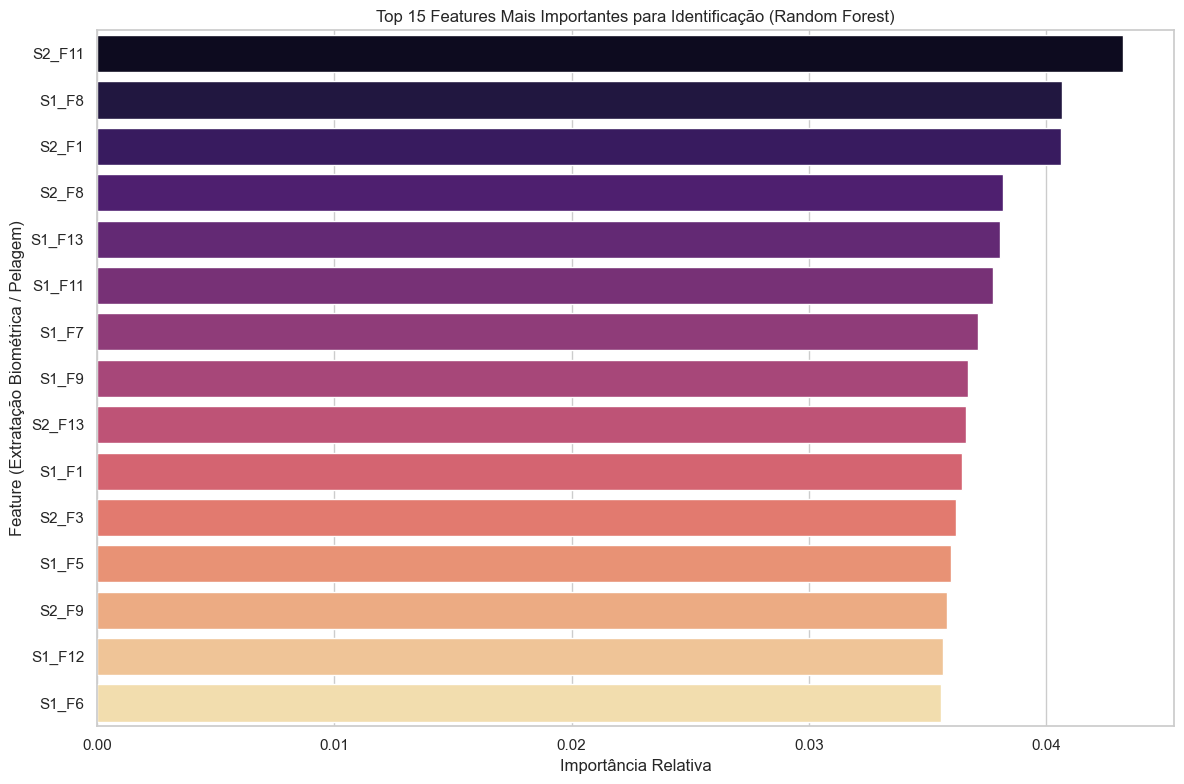

In [12]:
if 'df' in locals():
    # Remover classes com muito poucas amostras para garantir o split seguro
    min_samples = 5
    valid_classes = class_counts[class_counts >= min_samples].index
    df_valid = df[df['cow_id'].isin(valid_classes)].copy()

    X = df_valid[features_cols]
    y_valid = df_valid['cow_id']

    X_train, X_test, y_train, y_test = train_test_split(X, y_valid, test_size=0.2, random_state=42, stratify=y_valid)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    print("Relatório de Classificação Baseline (Feature Usability):")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Feature Importance (Rankeamento do que mais identifica a vaca)
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1][:15] # Top 15

    plt.figure(figsize=(12, 8))
    sns.barplot(x=importances[indices], y=np.array(features_cols)[indices], palette="magma")
    plt.title("Top 15 Features Mais Importantes para Identificação (Random Forest)")
    plt.xlabel("Importância Relativa")
    plt.ylabel("Feature (Extratação Biométrica / Pelagem)")
    plt.tight_layout()
    plt.show()

## Conclusão
Esta análise descritiva confirma a **usabilidade para identificação** das features geradas pelo modelo customizado de Keypoints e extração visual. Através do Feature Importance e das métricas do PCA/t-SNE, evidenciamos matematicamente quais padrões espaciais melhor distinguem cada vaca da nossa população.
O próximo passo na arquitetura da solução (Item 5) deverá explorar a construção final dos pipelines de subida e deploy dos classificadores (como MLP e CNN, se necessário).